In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [24]:
df = pd.read_csv("noisy_curvefit_data.csv")

In [25]:
print(df.info)
# the shape of the dataset is (100, 6)
# the dataset has 100 rows and 6 columns
# the columns are named x,  y_noise_1,  y_noise_2,  y_noise_3,  y_noise_4, and  y_noise_5, 

<bound method DataFrame.info of            x  y_noise_1  y_noise_2  y_noise_3  y_noise_4  y_noise_5
0  -1.000000  11.624419   8.296963  12.201067   7.811725   3.155566
1  -0.929293  10.377466   9.674440  12.198084   8.275006   7.518855
2  -0.858586  10.585100   9.251983  13.186565  12.926586   9.963630
3  -0.787879  10.913928   7.786344  12.552304  11.832379   9.625801
4  -0.717172   8.640287   8.551869   4.741432   8.790834   6.624113
..       ...        ...        ...        ...        ...        ...
95  5.717172  -1.411918   0.822231  -2.027132  -1.825106   2.746147
96  5.787879   0.344879  -1.718956   2.747559  -6.803779  -5.137472
97  5.858586   0.307133   0.353528   0.967976   5.461567  -0.905616
98  5.929293   0.048657   0.159961   2.482130  -0.414616  -4.334548
99  6.000000  -0.193438  -2.244792   1.930035   4.992414  -6.872850

[100 rows x 6 columns]>


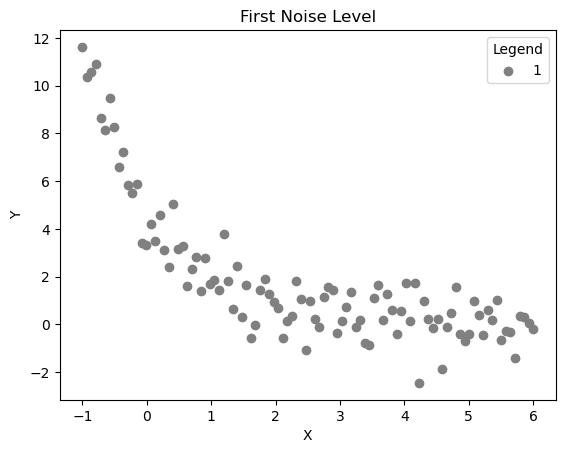

In [45]:
x = df["x"]
y = df["y_noise_1"]

plt.scatter(x, y, c="grey")
plt.ylabel("Y")
plt.xlabel("X")
plt.title("First Noise Level")
plt.legend("1", title = "Legend")

plt.show()

In [47]:
# Define the model
def model(x, A, k):
    return A * np.exp(-k * x)

# Fit the model to y_noise_1 data
p0 = [1, 1]
y_noise_1 = df["y_noise_1"]

popt, pcov = curve_fit(model, x, y_noise_1, p0=p0)

In [50]:
# Extract the best-fit parameters
A_fit, k_fit = popt

# Print the fitted model with two decimal places
print(f"Fit: y = {A_fit:.2f} * e^(-{k_fit:.2f} * x)")

Fit: y = 4.71 * e^(-0.92 * x)


In [54]:
# Calculate the reduced chi-squared
residuals = y_noise_1 - model(x, A_fit, k_fit)
chi2 = np.sum(residuals**2)
dof = len(x) - len(popt)
chi2_reduced = chi2 / dof
chi2_reduced

np.float64(0.7906732087457324)

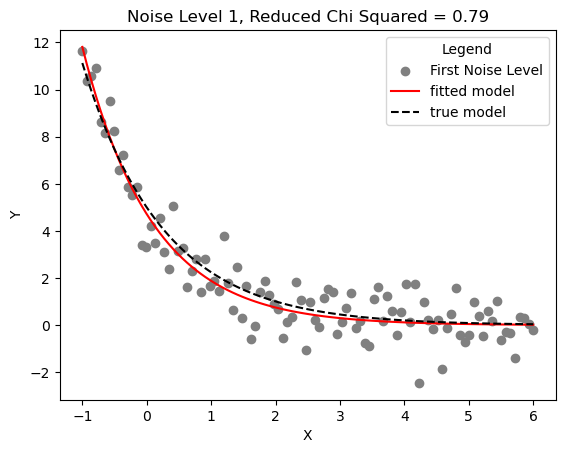

In [84]:
# Plot the result

plt.scatter(x, y, c="grey", label = "First Noise Level")
plt.ylabel("Y")
plt.xlabel("X")
plt.title("Noise Level 1, Reduced Chi Squared = 0.79")
plt.plot(x, model(x, A_fit, k_fit), c = "r", label = "fitted model")
plt.plot(x, model(x, 5, 0.8), c = "black", linestyle = "--", label = "true model")
plt.legend(title = "Legend")

plt.show()

In [ ]:
def fit_model(x, y):
    